In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import scipy.stats as stats
from viz import HealthVisualizer
from metrics import HealthAnalyzer

np.random.seed(42)

df = pd.read_csv('health_study_dataset.csv')

# Beskrivande analys  
I koden nedan beräknas medelvärde, median, min- och maxvärden för variablerna age, weight, height, systolic_bp och cholesterol. Datasetet består av 800 observationer och innehåller information om individernas ålder, vikt, längd, blodtryck och kolesterolvärden samt kategoriska variabler som rökstatus (rökare/icke-rökare) och sjukdomsstatus (sjuk/icke sjuk).

För att få en tydligare överblick över datamaterialet skapades även 4 histogram och 2 stapeldiagram vilket ger en visuell förståelse för variablernas fördelning och eventuella samband.

In [2]:
# Eftersom det inte finns en kolumn för ohälsosam vikt så skapar jag kolumnen BMI baserat på längd och vikt
df['BMI'] = (df['weight'] / (df['height'] / 100)**2).round(1)

display(df.head())
print(f'Tabellen visar de 5 översta raderna från datasetet. Urvalet innehåller {len(df)} personer.')
display(df.describe().round(1))
print('Tabellen visar urvalets medelvärde, median, min- och maxvärden samt percentiler.')

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease,BMI
0,1,57,F,168.9,65.8,141.8,4.58,No,0,23.1
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0,29.5
2,3,59,F,169.9,82.2,151.7,6.16,No,0,28.5
3,4,72,M,157.7,93.1,151.0,6.63,No,0,37.4
4,5,46,M,192.6,104.1,144.1,5.21,No,0,28.1


Tabellen visar de 5 översta raderna från datasetet. Urvalet innehåller 800 personer.


,id,age,height,weight,systolic_bp,cholesterol,disease,BMI
count,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0
mean,400.5,49.4,171.8,73.4,149.2,4.9,0.1,24.9
std,231.1,14.5,9.8,13.7,12.8,0.8,0.2,4.7
min,1.0,18.0,144.4,33.7,106.8,2.5,0.0,12.6
25%,200.8,39.0,164.8,64.8,140.9,4.3,0.0,21.9
50%,400.5,50.0,171.4,73.2,149.4,5.0,0.0,24.7
75%,600.2,59.0,178.9,82.6,157.6,5.5,0.0,28.0
max,800.0,90.0,200.4,114.4,185.9,7.9,1.0,40.1


Tabellen visar urvalets medelvärde, median, min- och maxvärden samt percentiler.


Det är inga värden som driekt sticker ut över det normala.

Nedan skapas 4 histogram samt 2 stapeldiagram

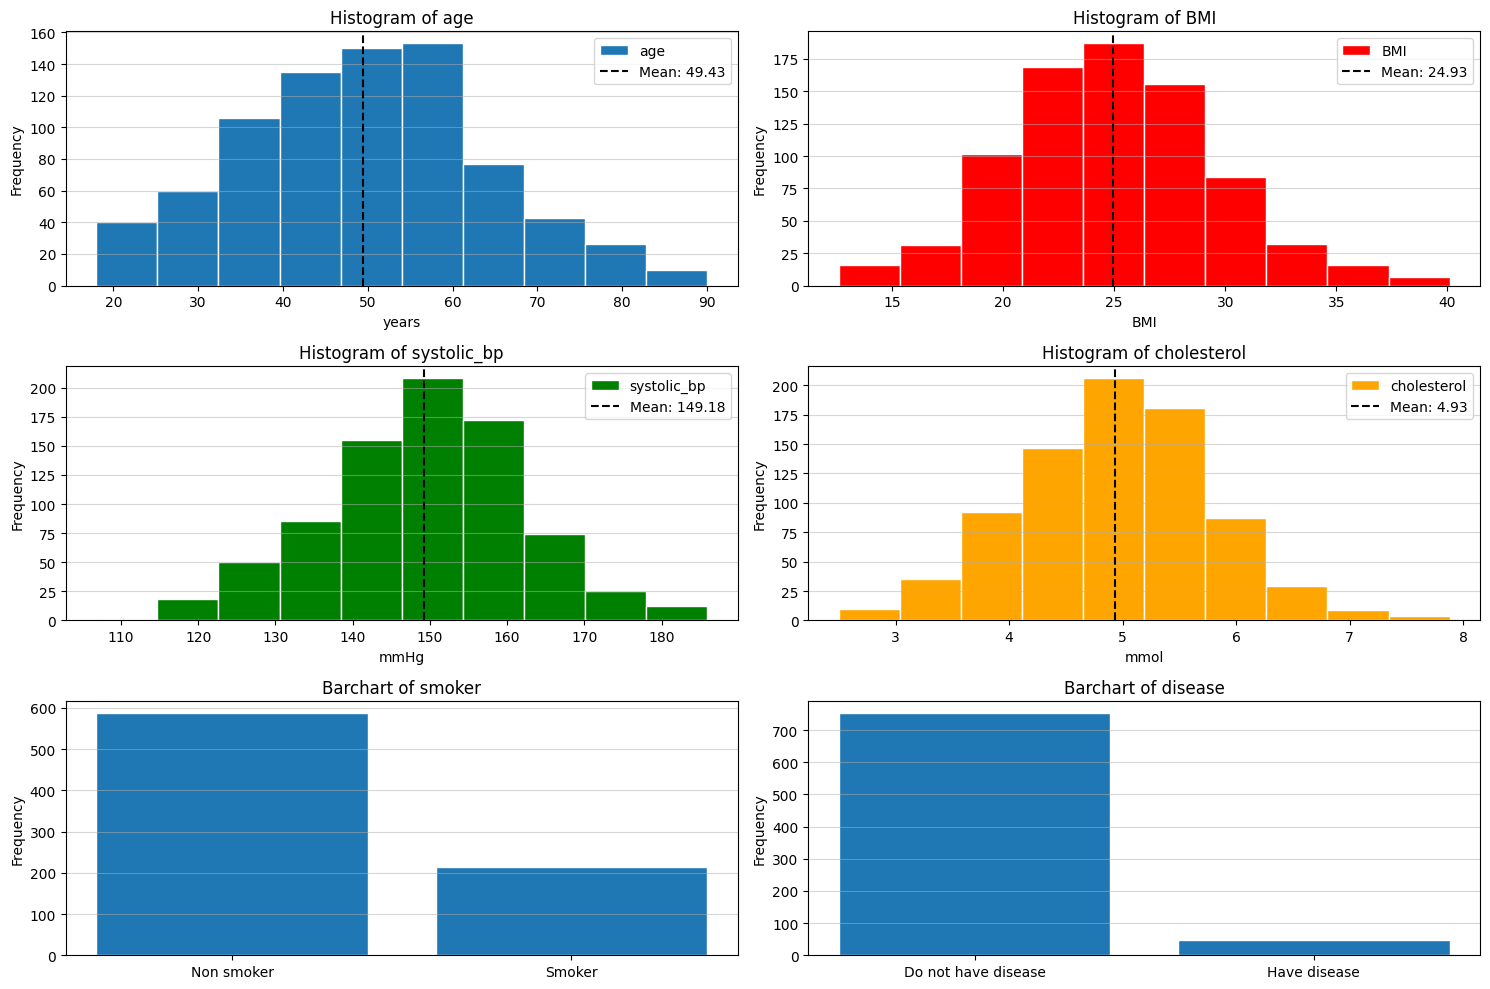

,mean,median,min,max,units
age,49.4,50.0,18.0,90.0,years
BMI,24.9,24.7,12.6,40.1,BMI
systolic_bp,149.2,149.4,106.8,185.9,mmHg
cholesterol,4.9,5.0,2.5,7.9,mmol


smoker
No     587
Yes    213
Name: count, dtype: int64

disease
0    753
1     47
Name: count, dtype: int64

In [3]:
# Skapa rityta
fig, axes = plt.subplots(3,2, figsize=(15,10))

# skapa instanser
age_vis = HealthVisualizer(df['age'])
bmi_vis = HealthVisualizer(df['BMI'])
systolic_bp_vis = HealthVisualizer(df['systolic_bp'])
cholesterol_vis = HealthVisualizer(df['cholesterol'])
smoker_vis = HealthVisualizer(df['smoker'])
disease_vis = HealthVisualizer(df['disease'])

# Histograms
age_vis.hist22(axes[0, 0], show_mean=True)
bmi_vis.hist22(axes[0, 1], show_mean=True, color='red')
systolic_bp_vis.hist22(axes[1, 0], show_mean=True, color='green')
cholesterol_vis.hist22(axes[1, 1], show_mean=True, color='orange')

# Barcharts
smoker_vis.bar22(axes[2, 0], xticks_labels=['Non smoker', 'Smoker'])
disease_vis.bar22(axes[2, 1], xticks_labels=['Do not have disease', 'Have disease'])

plt.tight_layout()
plt.show()

# mean, median, min, max
df_cols = df[['age', 'BMI', 'systolic_bp', 'cholesterol']].agg(['mean', 'median', 'min', 'max']).T.round(1)
df_cols['units'] = df_cols.index.map(HealthVisualizer.units)

display(df_cols)
display(df['smoker'].value_counts())
display(df['disease'].value_counts())

Det är inget som sticker ut i vår beskrivande analys. vi foprtsätter med en ljupare analys.

# **Utökad analys och visualisering**  

Denna analys ska ta reda på om det finns ett samband mellan:  
1. Blodtryck vs rökning , ålder och BMI.  
2. Cholesterol vs rökning , ålder och BMI.  
3. Sjukdom vs blodtryck och cholesterol

# 1. Blodtryck vs rökning , ålder och BMI. 
## Blodtryck vs rökning
Vi börjar att undersöka om blodtryck påverkas av rökning. Och eftersom rökning är binärt (sant eller falskt) så gör vi ett t-test då binära värden inte passar för linjär regression.

In [4]:
# T-test
smokers = df[df['smoker'] == 'Yes']['systolic_bp']
non_smokers = df[df['smoker'] == 'No']['systolic_bp']
t_stat, p_value = stats.ttest_ind(smokers, non_smokers, equal_var=False)

print(
    f't_stat: {t_stat.round(3)} \n',
    f'p_value: {p_value.round(3)} \n',
    f'Smoker mean: {smokers.mean().round(3)} \n',
    f'Non smoker mean: {non_smokers.mean().round(3)}'
)

t_stat: 0.45 
 p_value: 0.653 
 Smoker mean: 149.525 
 Non smoker mean: 149.053


## Blodtryck vs ålder & Blodtryck vs BMI

Här gör vi en linjär regression eftersom värdena är kontinuerliga på båda axlarna vilket passar bra för en scatterplot och därmed linjär regression


Age:
    intercept = 122.68
    slope = 0.54
    R² = 0.369
BMI:
    intercept = 140.36
    slope = 0.35
    R² = 0.017



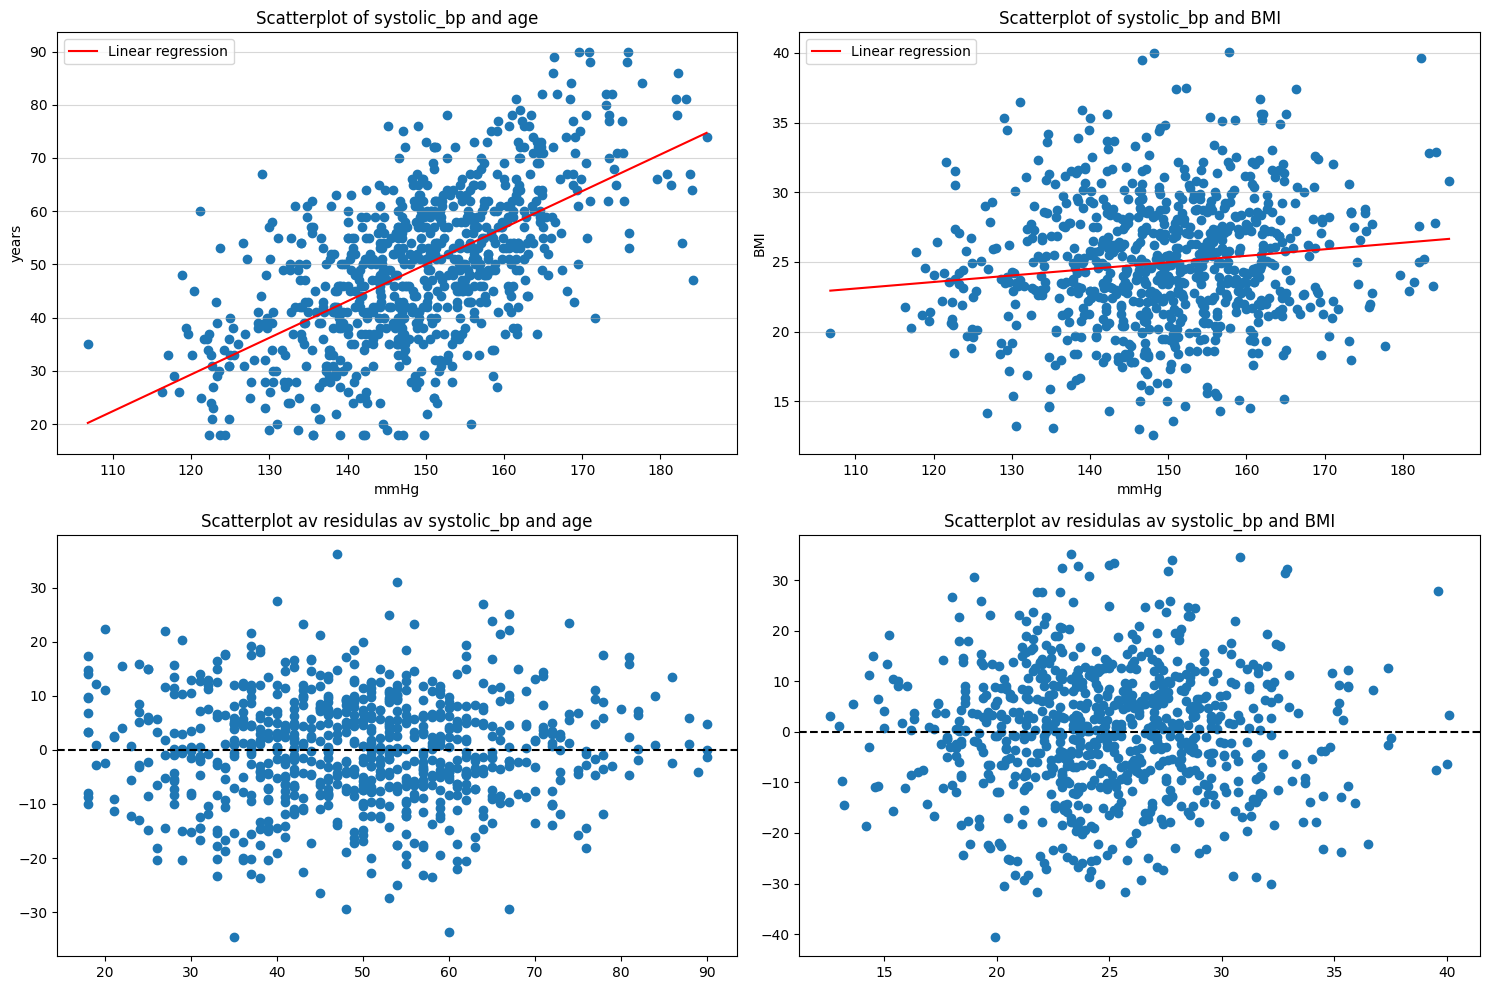

In [5]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

# Plotta scatter med regression
systolic_bp_vis.scatter22(age_vis, axes[0, 0], linear=True)
systolic_bp_vis.scatter22(bmi_vis, axes[0, 1], linear=True)

# Beräkna residualer
intercept_age, slope_age, r2_age, residuals_age = HealthAnalyzer.linear_regression(df['age'], df['systolic_bp'])
intercept_bmi, slope_bmi, r2_bmi, residuals_bmi = HealthAnalyzer.linear_regression(df['BMI'], df['systolic_bp'])

# Plotta residualer
axes[1,0].scatter(df['age'], residuals_age)
axes[1,0].axhline(0, color='black', linestyle='--')
axes[1,0].set_title('Scatterplot av residulas av systolic_bp and age')
axes[1,1].scatter(df['BMI'], residuals_bmi)
axes[1,1].axhline(0, color='black', linestyle='--')
axes[1,1].set_title('Scatterplot av residulas av systolic_bp and BMI')

print(f"""
Age:
    intercept = {intercept_age:.2f}
    slope = {slope_age:.2f}
    R² = {r2_age:.3f}
BMI:
    intercept = {intercept_bmi:.2f}
    slope = {slope_bmi:.2f}
    R² = {r2_bmi:.3f}
""")


plt.tight_layout()
plt.show()



## **Sammanfattning av Blodtryck vs rökning , ålder och BMI.**

### **Blodtryck vs rökning**
Medelvärde blodtryck hos rökare: 149,53 mmHg  
Medelvärde blodtryck hos ickerökare: 149,05 mmHg  
Skillnad: 0.47 mmHg  
p-värde: 0.65  
t-värde: 0.45

Med welchmetoden antar vi att det inte finns någon statistisk signifikant skillnad i blodtryck mellan rökare och icke rökare.  
P-värdet 0.65 betyder att det finns en 65% sannolikhet att slumpen ger en skillnad minst lika stor som skillnaden i medelvärde mellan grupperna rökare och ickerökare. Alltså 0.47 mmHg.
Eftersom 65% är en stor sannolikhet kan vi anta att skillnaden mycket väl kan bero på slumpen. För att skillnaden ska vara statistisk signifikant behöver P-värdet vara mindre än 0.05.

**Slutsats: Rökning verkar inte ha någon statistiskt och praktiskt betydande effekt på blodtrycket**

### **Blodtryck vs ålder**
intercept = 122.68  
slope = 0.54  
R² = 0.369  

Regressionsmodellen visar att blodtrycket i genomsnitt ökar med cirka 0.54 mmHg per ökat år i ålder. Det innebär en tydlig positiv trend: äldre personer har vanligtvis högre blodtryck.

R²-värdet på 0.369 betyder att modellen förklarar ungefär 37 % av variationen i blodtrycket. Vilket tyder på att ålder är en viktig faktor.

Residualplottarna visar en slumpmässig spridning runt nollinjen vilket talar för att den linjära modellen är rimlig.

**Slutsats: Ålder verkar ha en statistiskt och praktiskt betydande effekt på blodtrycket.**

### **Blodtryck vs BMI**
intercept = 140.36  
slope = 0.35  
R² = 0.017  

Regressionsmodellen visar att blodtrycket i genomsnitt ökar med cirka 0.35 mmHg per ökad BMI enhet. Detta är en mycket liten effektstorlek och indikerar en svag positiv trend mellan BMI och blodtryck  

R²-värdet på 0.017 betyder att modellen förklarar ungefär 1.7 % av variationen i blodtrycket. Detta är mycket lågt och tyder på att BMI inte är en stark prediktor för blodtryck.

Residualplottarna visar en slumpmässig spridning runt nollinjen vilket talar för att den linjära modellen är rimlig.

**Slutsats: BMI verkar ha en mycket liten statistiskt och praktiskt effekt på blodtrycket.**


# 2. Cholesterol vs rökning , ålder och BMI. 
## Cholesterol vs rökning

In [6]:
# T-test
smokers = df[df['smoker'] == 'Yes']['cholesterol']
non_smokers = df[df['smoker'] == 'No']['cholesterol']
t_stat, p_value = stats.ttest_ind(smokers, non_smokers, equal_var=False)

print(
    f't_stat: {t_stat.round(3)} \n',
    f'p_value: {p_value.round(3)} \n',
    f'Smoker mean: {smokers.mean().round(3)} \n',
    f'Non smoker mean: {non_smokers.mean().round(3)}'
)

t_stat: 0.33 
 p_value: 0.741 
 Smoker mean: 4.945 
 Non smoker mean: 4.923


## Cholesterol vs ålder & Cholesterol vs BMI


Age:
    intercept = 3.51
    slope = 0.03
    R² = 0.241
BMI:
    intercept = 3.60
    slope = 0.05
    R² = 0.085



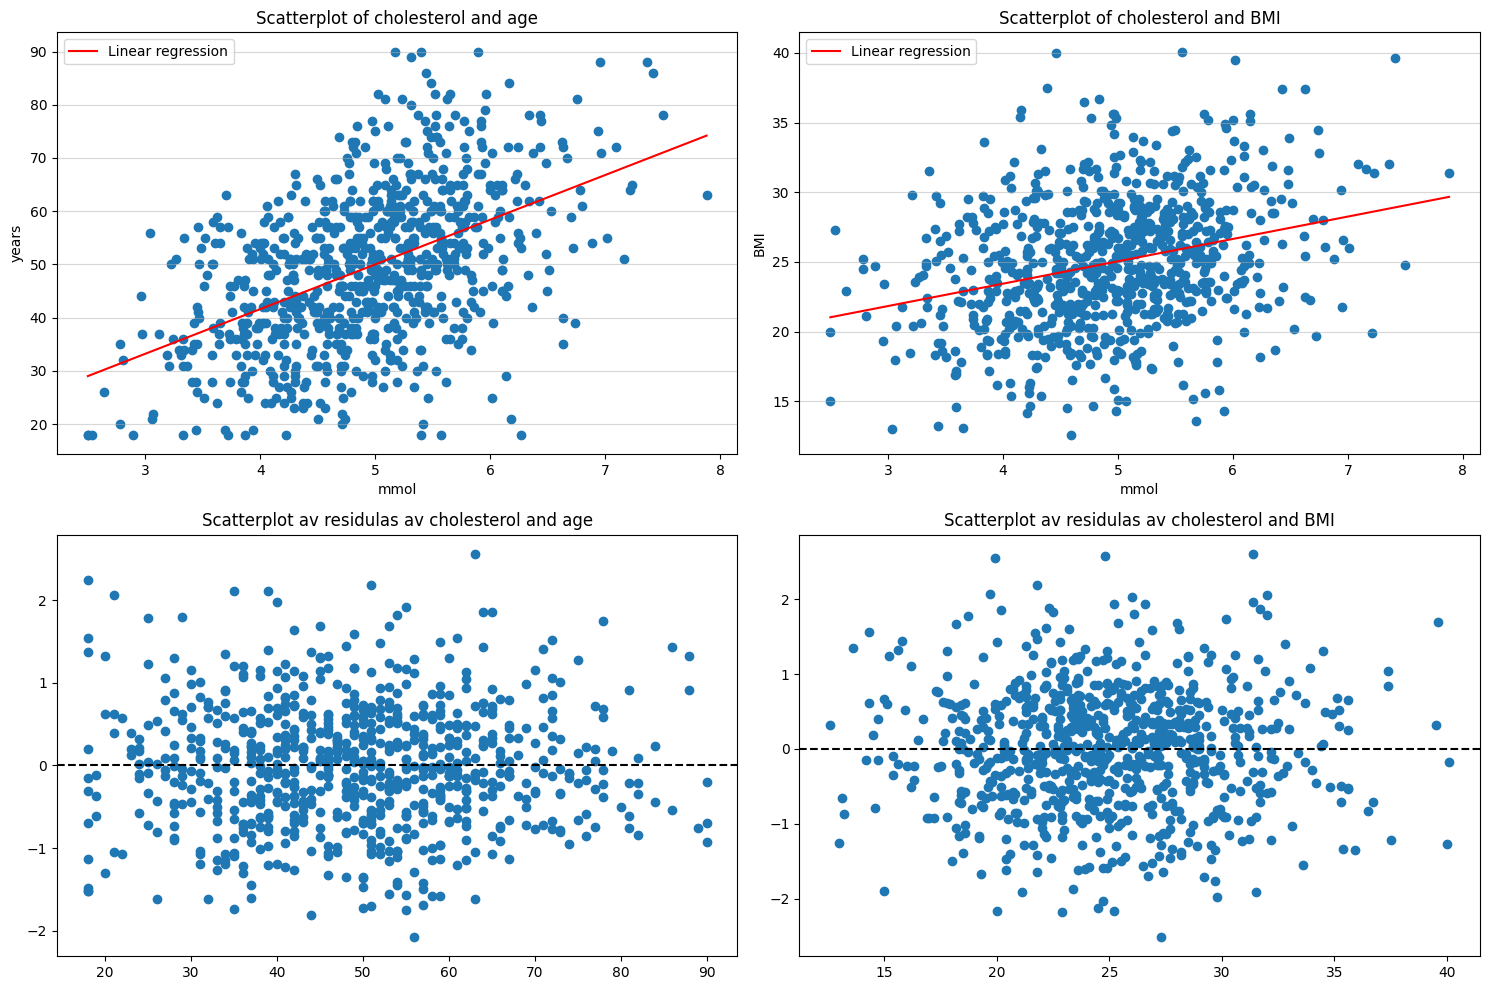

In [7]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

# Scatter med regression
cholesterol_vis.scatter22(age_vis, axes[0, 0], linear=True)
cholesterol_vis.scatter22(bmi_vis, axes[0, 1], linear=True)

# Beräkna residualer
intercept_age, slope_age, r2_age, residuals_age = HealthAnalyzer.linear_regression(df['age'], df['cholesterol'])
intercept_bmi, slope_bmi, r2_bmi, residuals_bmi = HealthAnalyzer.linear_regression(df['BMI'], df['cholesterol'])

# Plotta residualer, det blev fel och krångligt att fixa att köra residualerna via scatter22 då de är en numpy arrray.
axes[1,0].scatter(df['age'], residuals_age)
axes[1,0].axhline(0, color='black', linestyle='--')
axes[1,0].set_title('Scatterplot av residulas av cholesterol and age')
axes[1,1].scatter(df['BMI'], residuals_bmi)
axes[1,1].axhline(0, color='black', linestyle='--')
axes[1,1].set_title('Scatterplot av residulas av cholesterol and BMI')

print(f"""
Age:
    intercept = {intercept_age:.2f}
    slope = {slope_age:.2f}
    R² = {r2_age:.3f}
BMI:
    intercept = {intercept_bmi:.2f}
    slope = {slope_bmi:.2f}
    R² = {r2_bmi:.3f}
""")


plt.tight_layout()
plt.show()



## **Sammanfattning av Cholesterol vs rökning , ålder och BMI.**

### **Cholesterol vs rökning**  

Medelvärde blodtryck hos rökare: 149,53 mmHg  
Medelvärde blodtryck hos ickerökare: 149,05 mmHg  
Skillnad: 0.48 mmHg  
p-värde: 0.74
t-värde: 0.33 

Skillnaden i medelblodtryck är mycket lågt samt att p-värdet är högt vilket talar om att skillnaden i medelblodtryck sannolikt beror på slumpen och inte är statistiskt signifikant.  

**Slutsats: Rökning verkar inte ha någon statistiskt och praktiskt betydande effekt på Cholesterol**

### **Cholesterol vs ålder**

intercept = 3.51  
slope = 0.03  
R² = 0.241  

Regressionsmodellen visar att cholesterol i genomsnitt ökar med cirka 0.03 mmol/L per ökat år i ålder. Det innebär en tydlig positiv trend: äldre personer har vanligtvis högre cholesterol.

R²-värdet på 0.241 betyder att modellen förklarar ungefär 24 % av variationen i cholesterol. Vilket tyder på att ålder är en viktig faktor.

Residualplottarna visar en slumpmässig spridning runt nollinjen vilket talar för att den linjära modellen är rimlig.

**Slutsats: Ålder verkar ha en statistiskt och praktiskt betydande effekt på cholesterol.**

### **Cholesterol vs BMI**

intercept = 3.60   
slope = 0.05  
R² = 0.085  

Regressionsmodellen visar att cholesterol i genomsnitt ökar med cirka 0.05 mmol/L per ökad BMI enhet. Det innebär en svag positiv trend.

R²-värdet på 0.085 betyder att modellen förklarar ungefär 8.5 % av variationen i cholesterol. Detta är måttligt lågt och tyder på att BMI inte är en stark prediktor för cholesterol.

Residualplottarna visar en slumpmässig spridning runt nollinjen vilket talar för att den linjära modellen är rimlig.

**Slutsats: BMI verkar ha en mycket liten statistiskt och praktiskt effekt på cholesterol.**


# 3. Sjukdom vs blodtryck och cholesterol
## Disease vs blodtryck

In [8]:
disease_group = df[df['disease'] == 1]['systolic_bp']
healthy_group = df[df['disease'] == 0]['systolic_bp']

min_disease_group, max_disease_group, mean_disease_group = HealthAnalyzer.ci_bootstrap(disease_group)
min_healthy_group, max_healthy_group, mean_healthy_group = HealthAnalyzer.ci_bootstrap(healthy_group)

print(f'''
    Medelvärde blodtryck med sjukdom: {round(mean_disease_group, 2)}
    Konfidensintervall: {round(min_disease_group, 2)} till {round(max_disease_group, 2)}
    Medelvärdet ligger innanför konfindesintervallet

    Medelvärde blodtryck utan sjukdom: {round(mean_healthy_group, 2)}
    Konfidensintervall: {round(min_healthy_group, 2)} till {round(max_healthy_group, 2)}
    Medelvärdet ligger innanför konfindesintervallet
''')

# T-test
t_stat, p_value = stats.ttest_ind(disease_group, healthy_group, equal_var=False)

print(
    f't_stat: {t_stat.round(3)} \n',
    f'p_value: {p_value.round(3)} \n',
    f'Smoker mean: {smokers.mean().round(3)} \n',
    f'Non smoker mean: {non_smokers.mean().round(3)}'
)


    Medelvärde blodtryck med sjukdom: 150.77
    Konfidensintervall: 147.0 till 154.54
    Medelvärdet ligger innanför konfindesintervallet

    Medelvärde blodtryck utan sjukdom: 149.08
    Konfidensintervall: 148.12 till 149.99
    Medelvärdet ligger innanför konfindesintervallet

t_stat: 0.854 
 p_value: 0.397 
 Smoker mean: 4.945 
 Non smoker mean: 4.923


**Slutsats: Vi ser att konfidensintervallen för blodtryck överlappar tydligt mellan personer med och utan sjukdom. Medelvärdena ligger också mycket nära varandra. Detta tyder på att det inte finns någon statistiskt säkerställd skillnad mellan grupperna. T-testet bekräftar detta, med ett p-värde på 0.397, vilket är långt över 0.05.**

# Disease vs cholesterol

In [9]:
disease_group = df[df['disease'] == 1]['cholesterol']
healthy_group = df[df['disease'] == 0]['cholesterol']

min_disease_group, max_disease_group, mean_disease_group = HealthAnalyzer.ci_bootstrap(disease_group)
min_healthy_group, max_healthy_group, mean_healthy_group = HealthAnalyzer.ci_bootstrap(healthy_group)

print(f'''
    Medelvärde cholesterol med sjukdom: {round(mean_disease_group, 2)}
    Konfidensintervall: {round(min_disease_group, 2)} till {round(max_disease_group, 2)}
    Medelvärdet ligger innanför konfindesintervallet

    Medelvärde cholesterol utan sjukdom: {round(mean_healthy_group, 2)}
    Konfidensintervall: {round(min_healthy_group, 2)} till {round(max_healthy_group, 2)}
    Medelvärdet ligger innanför konfindesintervallet
''')

# T-test
t_stat, p_value = stats.ttest_ind(disease_group, healthy_group, equal_var=False)

print(
    f't_stat: {t_stat.round(3)} \n',
    f'p_value: {p_value.round(3)} \n',
    f'Smoker mean: {smokers.mean().round(3)} \n',
    f'Non smoker mean: {non_smokers.mean().round(3)}'
)


    Medelvärde cholesterol med sjukdom: 4.98
    Konfidensintervall: 4.76 till 5.19
    Medelvärdet ligger innanför konfindesintervallet

    Medelvärde cholesterol utan sjukdom: 4.93
    Konfidensintervall: 4.86 till 4.99
    Medelvärdet ligger innanför konfindesintervallet

t_stat: 0.436 
 p_value: 0.665 
 Smoker mean: 4.945 
 Non smoker mean: 4.923


**Slutsats: Vi ser att konfidensintervallen för cholesterol överlappar tydligt mellan personer med och utan sjukdom. Medelvärdena ligger också mycket nära varandra. Detta tyder på att det inte finns någon statistiskt säkerställd skillnad mellan grupperna. T-testet bekräftar detta, med ett p-värde på 0.665, vilket är långt över 0.05.**

## Simulering kopplad till caset 
Beräkna andelen personer i datasetet som har sjukdomen.

In [10]:
# Eftersom värdet i 'disease' antingen är 1 eller 0 så kan vi ta medelvärdet direkt för att få ut % som har sjukdomen
participants_with_disease = df['disease'].mean()

# Skapar en np.array med 1000 random rader(element) med antingen 0 eller 1.
# Sannolikhet för 0 är: 1 - populationsannolikheten (5.88%) = 94.12%. Sannolikheten för 1 är populationsannolikheten (5.88%)
# Räknar ut medelvärdet
simulated_disease = np.random.choice([0, 1], size=1000, p=[1 - participants_with_disease, participants_with_disease]).mean()


print(f'Percentage of participants with disease (dataset): {(participants_with_disease * 100).round(2)} %')
print(f'Percentage of participants with disease (numpy sim): {(simulated_disease * 100).round(2)} %')

Percentage of participants with disease (dataset): 5.88 %
Percentage of participants with disease (numpy sim): 5.7 %


# **Resultat**

1. Blodtryck vs rökning , ålder och BMI.
- **Blodtryck vs rökning:** Rökning verkar inte ha någon statistiskt och praktiskt betydande effekt på blodtrycket
- **Blodtryck vs ålder:** Ålder verkar ha en statistiskt och praktiskt betydande effekt på blodtrycket.
- **Blodtryck vs BMI:** BMI verkar ha en mycket liten statistiskt och praktiskt effekt på blodtrycket.
2. Cholesterol vs rökning , ålder och BMI.
- **Cholesterol vs rökning:** Rökning verkar inte ha någon statistiskt och praktiskt betydande effekt på Cholesterol.
- **Cholesterol vs ålder:** Ålder verkar ha en statistiskt och praktiskt betydande effekt på cholesterol.
- **Cholesterol vs BMI:** BMI verkar ha en mycket liten statistiskt och praktiskt effekt på cholesterol.
3. Sjukdom vs blodtryck och cholesterol
- **Disease vs blodtryck:** Blodtryck verkar inte ha någon statistiskt och praktiskt betydande effekt på sjukdom.
- **Disease vs Cholesterol:** Cholesterol verkar inte ha någon statistiskt och praktiskt betydande effekt på sjukdom.

**Samlad slutsats**

Analysen visar att ålder har en tydlig statistiskt och praktiskt betydande effekt på både blodtryck och kolesterol. BMI har endast en mycket liten effekt på blodtryck och kolesterol, medan rökning inte verkar påverka dessa variabler i detta dataset.

När det gäller sjukdom visar resultaten att varken blodtryck eller kolesterol har någon statistiskt eller praktiskt betydande effekt på sjukdom.